<a href="https://colab.research.google.com/github/saddamtorres/Matplotlib/blob/main/Matplotlib_public.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Anatomía de una figura en Matplotlib


**Archivo requerido junto al notebook:** `EP_C_reconciliado.xlsx`


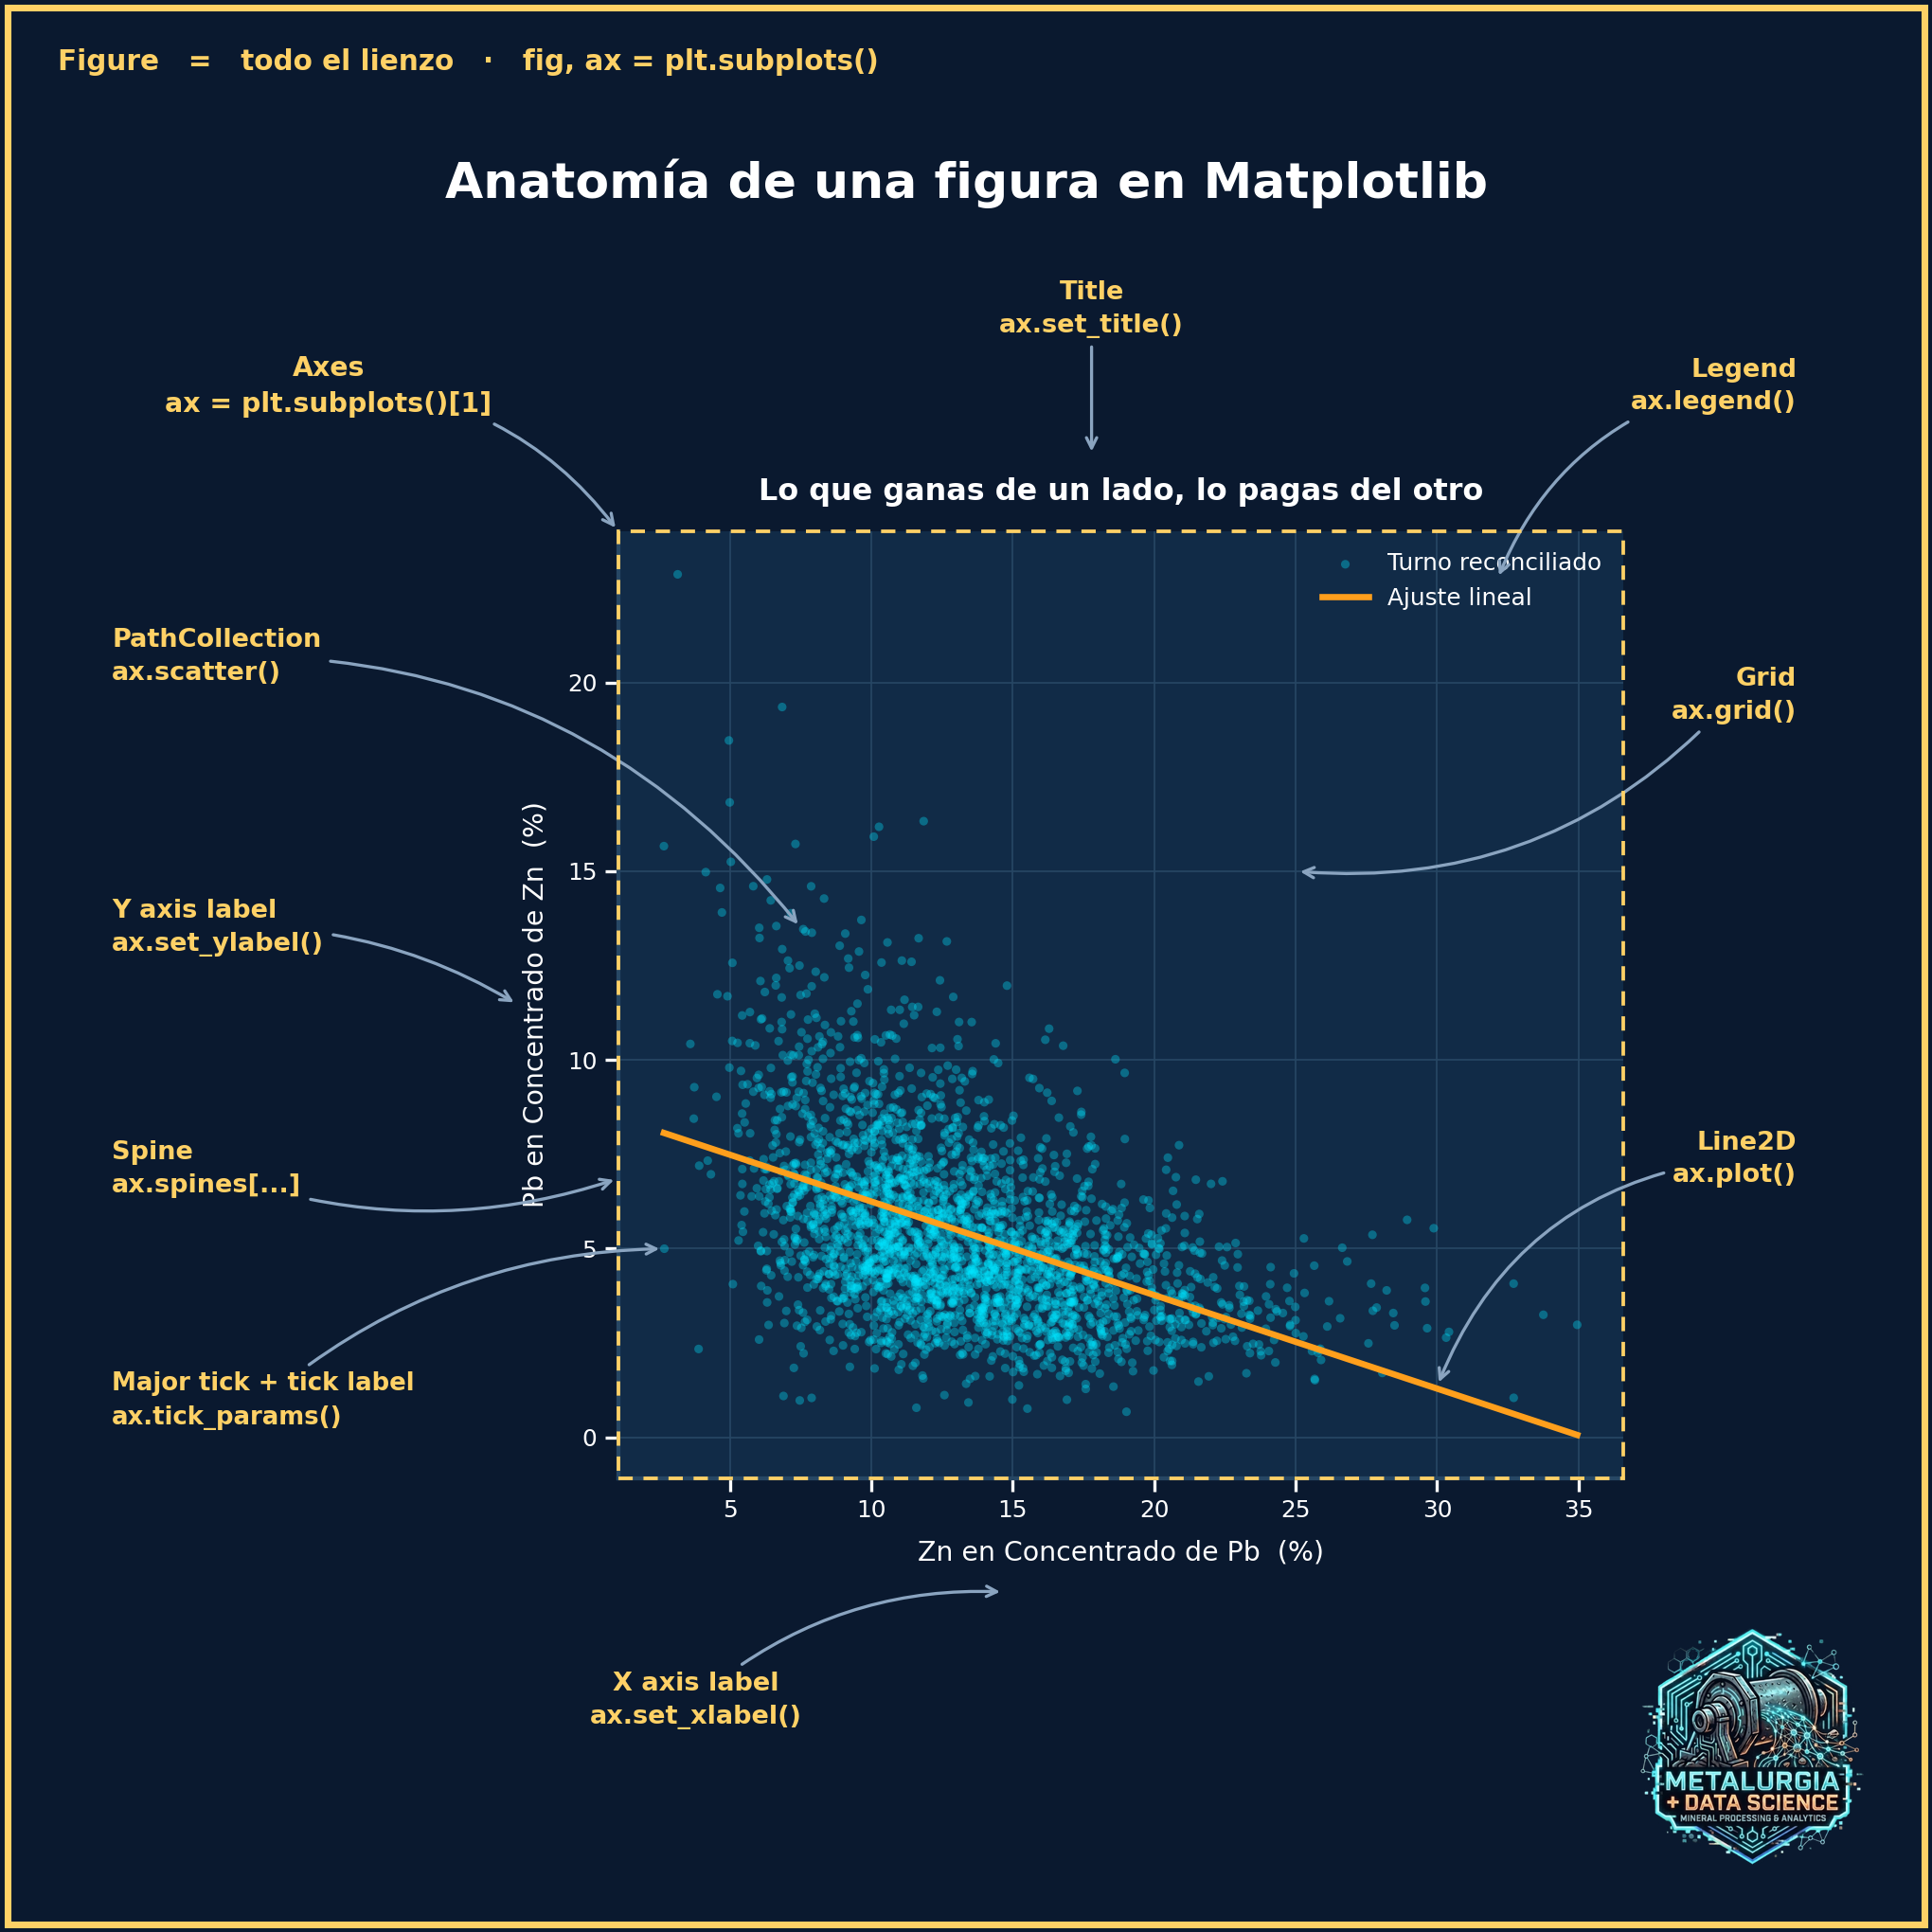

In [ ]:
'''
Figure  (el lienzo completo)
 └── Axes  (la región de datos; puede haber varios)
      ├── XAxis / YAxis
      └── Artists: Line2D, PathCollection, Text, Spine, Legend...

## Setup

In [ ]:
# Paleta del canal
NAVY   = "#0A192F"   # fondo del Figure  (el lienzo completo)
PANEL  = "#112B47"   # fondo del Axes    (distinto A PROPOSITO: hace visible la frontera)
CYAN   = "#00E5FF"   # valores medidos
ORANGE = "#FF9F1C"   # resultados / ajustes
GRID   = "#274764"   # rejilla y marcos

# Color fijo por elemento: la misma especie siempre del mismo color en todo el canal
COLOR_EL = {"Au": "#FFC300", "Ag": "#C0C8D0", "Pb": "#8E9AAF",
            "Zn": "#00E5FF", "Cu": "#E07A5F", "Fe": "#D9622B"}

---
# Bloque I — La figura crece una línea por celda

Cada celda es un bloque completo. Lo nuevo va marcado con `# <-- NUEVO`.

### 1.1 · El lienzo
`plt.subplots()` devuelve una **tupla**: el papel (`fig`) y el gráfico (`ax`).

### 1.2 · Los fondos
El Figure y el Axes son objetos distintos y cada uno tiene su propio fondo.

### 1.2b · ¿Por qué el marco sigue negro?
Porque `set_facecolor` pinta el **relleno**, no el marco. El marco son cuatro `Spine`,
artistas aparte, que siguen en su color por default. Se arreglan en 1.6.

### 1.3 · Los datos
`alpha` no es cosmético: con 2,568 puntos encimados la opacidad **es** información.
Donde se ve más brillante hay más turnos.

### 1.4 · El ajuste
La recta se calcula con `np.polyfit` y se dibuja como una línea más.

### 1.5 · Títulos, etiquetas y leyenda
Las etiquetas de la leyenda salen de los `label=` de 1.3 y 1.4:
la leyenda no inventa nada, lee lo que ya está dibujado.

### 1.6 · Marco, rejilla y ticks
`ax.spines` es un **diccionario** de artistas: cuatro marcos, cada uno con sus métodos.
`set_axisbelow(True)` manda la rejilla detrás de los datos.

### 1.7 · Anotar un turno concreto
Aquí aparecen **dos sistemas de coordenadas**:
`xy` en coordenadas de **datos** (la punta persigue al punto),
`xytext` en fracción del **Axes** (el texto se queda donde lo pusiste).

---
# Bloque II — Qué hay dentro de la figura

Hasta aquí dimos órdenes. Ahora vemos a **quién** se las dimos.

### 2.1 · Todo lo que ves es un Artist
`ax.get_children()` lista los objetos que cuelgan del Axes. Ahí están todos.

### 2.2 · rcParams — el atajo
Todo el estilo del Acto I son ~15 llamadas repetidas en cada celda.
`rcParams` las aplica a **todas** las figuras que se creen a partir de aquí.
Es, literalmente, lo que hace `sns.set_theme()` por debajo.

In [ ]:
mpl.rcParams.update({
    'figure.facecolor': NAVY,      # lo que hacíamos con fig.set_facecolor()
    'axes.facecolor': PANEL,       # ...y con ax.set_facecolor()
    'axes.edgecolor': GRID,        # 1.6: color de los spines
    'axes.labelcolor': 'white',    # 1.5: color de las etiquetas de eje
    'xtick.color': 'white',        # 1.6: ticks
    'ytick.color': 'white',
    'text.color': 'white',         # de aquí toma su color la leyenda
    'grid.color': GRID,            # 1.6: rejilla
    'axes.grid': True,             # rejilla encendida por default
    'axes.axisbelow': True,        # 1.6: siempre debajo de los datos
    'axes.spines.top': False,      # 1.6: spines superiores fuera
    'axes.spines.right': False,
    'legend.frameon': False,       # el default es True y en fondo oscuro estorba
    'font.size': 11,
    'savefig.facecolor': NAVY,     # 1.7: que savefig no invente fondo blanco
})


---
# Bloque III — Varios gráficos en una figura

Cuando pides más de un gráfico, `plt.subplots()` ya no devuelve un Axes:
devuelve un **arreglo** de Axes. Y a partir de ahí hay que llamar a cada panel por su nombre.

### 3.1 · Matriz 1×2 — el efecto portador
**El mismo predictor** (`Cab_Pb`, la ley de cabeza de plomo) contra **dos respuestas distintas**:
la recuperación de Pb y la de Ag, ambas en el circuito de plomo.

`sharey=True` **no es cosmético**: sin él cada panel se autoescala, la meseta del plomo
se vería igual de empinada que la rampa de la plata y la comparación mentiría.

### 3.2 · Matriz 2×2 — leyes de cabeza
Aquí el rango de cada elemento está en el eje **X**: Au va de 0.07 a 1.12 g/t y
Ag de 39 a 170 g/t. Por eso **`sharex` sería el error**, mientras que `sharey` sí se
justifica: los cuatro paneles cuentan los mismos 2,568 turnos.

---
## Referencias

**Matplotlib — documentación oficial**
- *Quick start guide* → sección **Coding styles**: las interfaces explícita (OO) e implícita (pyplot).
  https://matplotlib.org/stable/users/explain/quick_start.html
- *Anatomy of a figure* — la figura anotada con cada elemento por su nombre.
  https://matplotlib.org/stable/gallery/showcase/anatomy.html
- *Customizing Matplotlib with style sheets and rcParams*.
  https://matplotlib.org/stable/users/explain/customizing.html
- *Introduction to Artists* y *Transformations Tutorial* (índice de guías de usuario).
  https://matplotlib.org/stable/users/index.html



---
## Si alguna línea no te quedó clara

Este notebook usa tres herramientas de Python puro (no de matplotlib) que quizá no
has visto antes. Si en algún punto entendiste el concepto de proceso pero no la
sintaxis, aquí puedes repasarlas gratis, en el navegador, sin instalar nada:

| Tema | Dónde aparece en este notebook | Curso |
|---|---|---|
| **Funciones** (`def`, `return`) | `quintiles()` en el Bloque III | [Kaggle Learn — Functions and Getting Help](https://www.kaggle.com/learn/python) |
| **Bucles `for`** | `for sp in ("top", "right"):` · `for axi, el in zip(...)` | [Kaggle Learn — Loops and List Comprehensions](https://www.kaggle.com/learn/python) |
| **List comprehensions** | `[iv.mid for iv in med.index]` | [Kaggle Learn — Loops and List Comprehensions](https://www.kaggle.com/learn/python) |